In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [ ]:
# Seed whole practice
torch.manual_seed(3423)

In [ ]:
names = ["." + name.replace("\n", "").lower().strip() + "." for name in open("/content/names.txt").readlines()]
len(names)

32033

In [ ]:
words = sorted(list(set([ch for name in names for ch in name])))
itos = dict(enumerate(words))
stoi = {v: k for k, v in itos.items()}
n_words = len(words)
n_words

NameError: name 'names' is not defined

## bigram model

In [ ]:
counts = torch.zeros(n_words, n_words)

In [ ]:
for name in names:
  for n1, n2 in zip(name[:-1], name[1:]):
    counts[stoi[n1], stoi[n2]] += 1

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

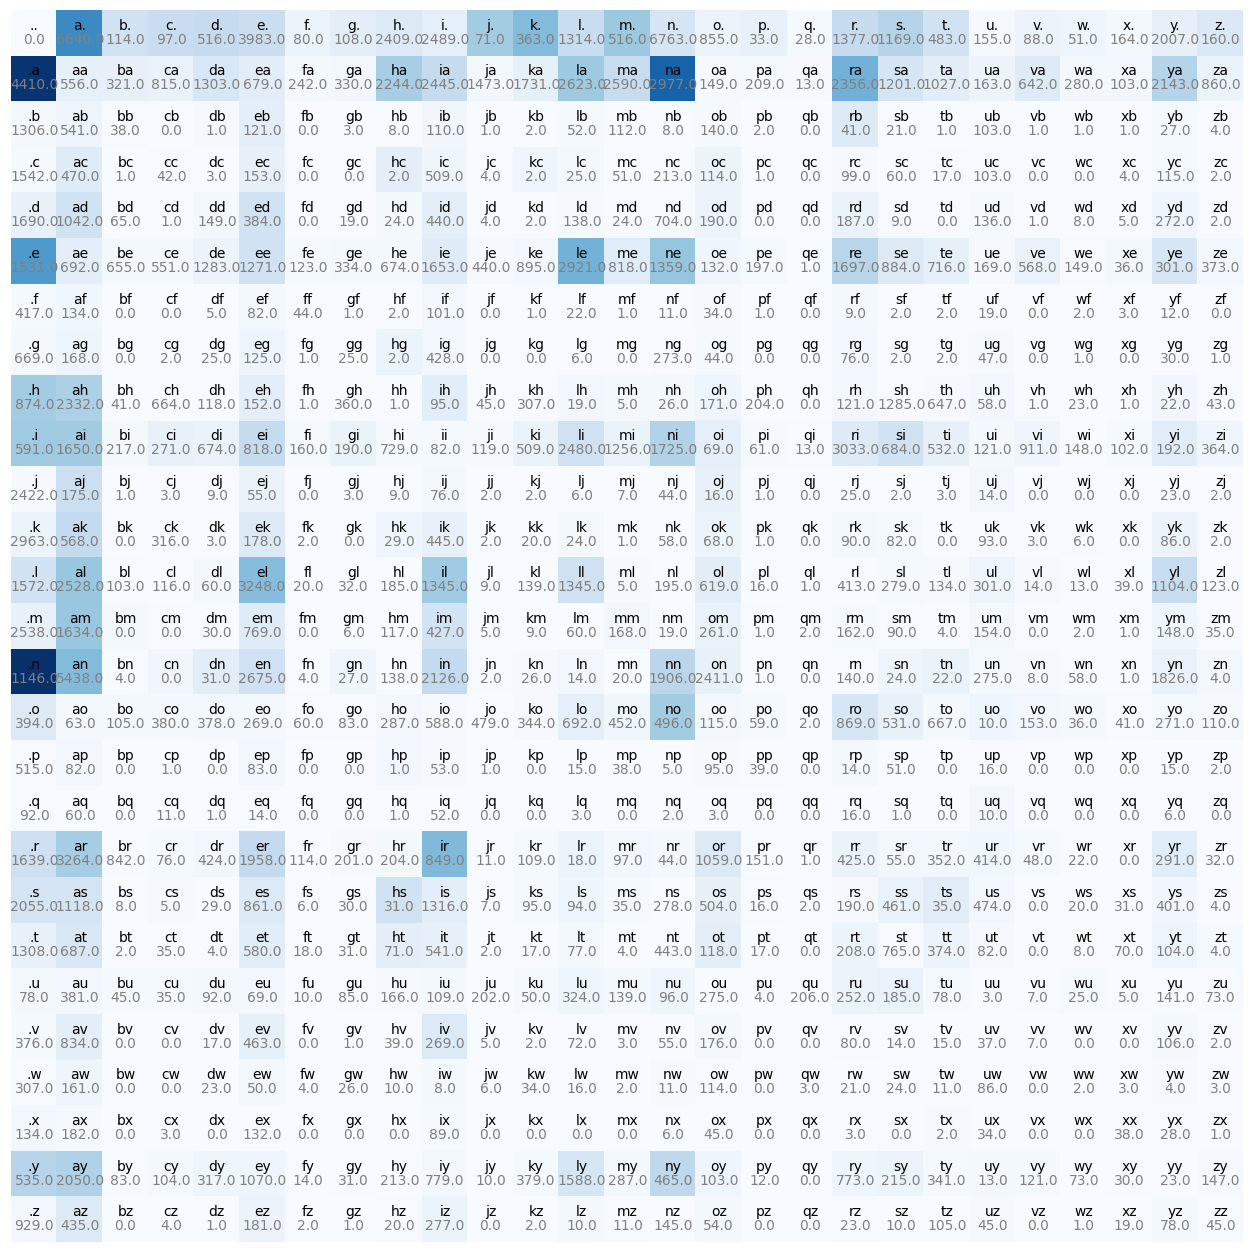

In [ ]:
plt.figure(figsize=(16, 16))
plt.imshow(counts, cmap="Blues")
for i in range(n_words):
  for j in range(n_words):
    plt.text(i, j, itos[i] + itos[j], ha="center", va="bottom")
    plt.text(i, j, counts[i, j].item(), ha="center", va="top", color="gray")
plt.axis("off")

In [ ]:
# use multinomial and predict names
for _ in range(5):
  name = []
  s = 0
  while True:
    s = torch.multinomial(counts[s], num_samples=1).item()
    if s == 0:
      break
    name.append(s)
  print(''.join([itos[i] for i in name]))

menynjahererdramokahapilyniyiackawyahondara
d
asa
soui
le


## Neural network

In [ ]:
# Design neural network
fan_in = 27
fan_out = 27

In [ ]:
# initialize parameters
w = torch.randn(fan_in, fan_out)
b = torch.randn(fan_out)
parameters = [w, b]
for p in parameters:
  p.requires_grad=True

In [ ]:
# hyperparameters for training & stack for tracking loss
epochs = 1000000
lr = 0.01
lossi = []

In [ ]:
# Train neural network
for i in range(epochs):
  # Generate new example
  idx = torch.randint(len(names), (1,))
  xs = torch.tensor([stoi[w] for w in names[idx][:-1]])
  ys = torch.tensor([stoi[w] for w in names[idx][1:]])
  xenc = F.one_hot(xs, num_classes=n_words).float()

  # Forwards pass
  logits = xenc @ w + b
  probs = logits.exp()/logits.exp().sum(dim=1, keepdim=True)
  ll = probs[range(len(ys)), ys].log().mean()

  # Backward pass
  for p in parameters:
    p.grad = None
  ll.backward()

  # update parameters
  with torch.no_grad():
    for p in parameters:
      p += lr * p.grad

  lossi.append(ll.item())
  if i%(epochs/10) == 0:
    print(f"Checkpoint {i}: {ll.item()}")

Checkpoint 0: -2.2142868041992188
Checkpoint 100000: -2.4852707386016846
Checkpoint 200000: -2.074662446975708
Checkpoint 300000: -2.7492213249206543
Checkpoint 400000: -2.096580982208252
Checkpoint 500000: -2.8732221126556396
Checkpoint 600000: -2.438706636428833
Checkpoint 700000: -2.530247449874878
Checkpoint 800000: -2.3478198051452637
Checkpoint 900000: -2.1610238552093506


In [ ]:
lossi[-5:]

[-2.679093837738037,
 -2.637202262878418,
 -2.3110833168029785,
 -3.248168706893921,
 -2.375743865966797]

In [ ]:
# use multinomial and predict names
for _ in range(5):
  name = []
  ix = torch.tensor(0)
  while True:
    xenc = F.one_hot(ix, num_classes=27).float()
    logits = xenc @ w + b
    probs = logits.exp()/logits.exp().sum()
    ix = torch.multinomial(probs, num_samples=1)[0]
    if ix.item() == 0:
      break
    name.append(ix.item())
  print(''.join([itos[i] for i in name]))

asefa
kevisast
e
mbr
glossarevocylyamisahisusa


## MLP

In [ ]:
def build_dataset(names):
  block_size = 3
  X, Y = [], []
  for name in names:
    context = [0] * block_size
    for ch in name[1:]:
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]
  return torch.tensor(X), torch.tensor(Y)

In [ ]:
n = len(names)
n80 = int(n*0.80)
n90 = int(n*0.90)
Xtr, ytr = build_dataset(names[:n80])
Xdev, ydev = build_dataset(names[n80:n90])
Xte, yte = build_dataset(names[n90:])

In [ ]:
block_size = 3
chars = 27
n_emb = 10
hidden = 200
out = 27
# parameters intializations

C = torch.randn(chars, n_emb)
w1 = torch.randn(block_size*n_emb, hidden)
b1 = torch.randn(hidden)
w2 = torch.randn(hidden, out)
b2 = torch.randn(out)
parameters = [C, w1, b1, w2, b2]
for p in parameters:
  p.requires_grad=True

In [ ]:
epochs = 10000
lr = 0.01
lossi = []

In [ ]:
for i in range(epochs):
  # Forward Pass
  ix = torch.randint(0, len(Xtr), (32,))
  emb = C[Xtr[ix]]
  h = emb.view(-1, block_size*n_emb) @ w1 + b1
  h = torch.tanh(h)
  logits = h @ w2 + b2
  nll = F.cross_entropy(logits, ytr[ix])

  # Backward Pass
  for p in parameters:
    p.grad = None
  nll.backward()

  # update parameters
  with torch.no_grad():
    for p in parameters:
      p += - lr * p.grad
  lossi.append(nll.item())
  if i%(epochs/20) == 0:
    print(f"Chkpt {i}        Loss {nll.item()}")

Chkpt 0        Loss 5.302988529205322
Chkpt 500        Loss 2.481076240539551
Chkpt 1000        Loss 3.1848044395446777
Chkpt 1500        Loss 2.6583168506622314
Chkpt 2000        Loss 2.494716167449951
Chkpt 2500        Loss 2.401857852935791
Chkpt 3000        Loss 2.519158363342285
Chkpt 3500        Loss 2.8587357997894287
Chkpt 4000        Loss 2.6132593154907227
Chkpt 4500        Loss 3.0634915828704834
Chkpt 5000        Loss 2.597554922103882
Chkpt 5500        Loss 2.485745668411255
Chkpt 6000        Loss 2.616807460784912
Chkpt 6500        Loss 2.3532934188842773
Chkpt 7000        Loss 2.368988513946533
Chkpt 7500        Loss 2.4729878902435303
Chkpt 8000        Loss 2.7297613620758057
Chkpt 8500        Loss 2.366001605987549
Chkpt 9000        Loss 2.3477277755737305
Chkpt 9500        Loss 2.6581871509552


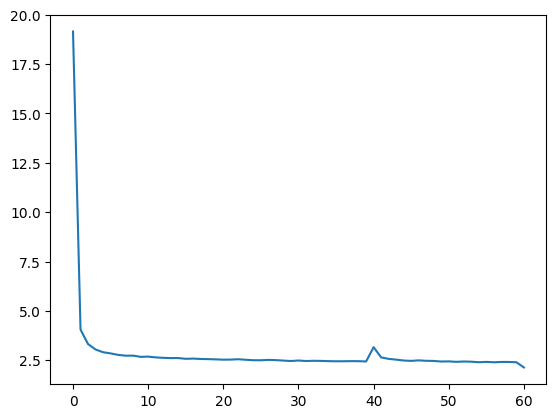

In [ ]:
plt.plot([torch.tensor(lossi[i:i+int(epochs/20)]).mean().item() for i in range(0, len(lossi), int(epochs/20))])

In [ ]:
emb = C[Xtr]
h = emb.view(-1, block_size*n_emb) @ w1 + b1
h = torch.tanh(h)
logits = h @ w2 + b2
F.cross_entropy(logits, ytr)

tensor(2.3964, grad_fn=<NllLossBackward0>)

In [ ]:
emb = C[Xdev]
h = emb.view(-1, block_size*n_emb) @ w1 + b1
h = torch.tanh(h)
logits = h @ w2 + b2
F.cross_entropy(logits, ydev)

tensor(2.6068, grad_fn=<NllLossBackward0>)

In [ ]:
emb = C[Xte]
h = emb.view(-1, block_size*n_emb) @ w1 + b1
h = torch.tanh(h)
logits = h @ w2 + b2
F.cross_entropy(logits, yte)

tensor(2.6167, grad_fn=<NllLossBackward0>)

In [ ]:
## Generate new words
for _ in range(5):
  out = []
  context = [0] * block_size
  while True:
    emb = C[torch.tensor(context)]
    h = emb.view(-1, block_size*n_emb) @ w1 + b1
    h = torch.tanh(h)
    logits = h @ w2 + b2
    probs = F.softmax(logits, dim=1)
    ix = torch.multinomial(probs, num_samples=1).item()
    if ix == 0:
      break
    context = context[1:] + [ix]
    out.append(ix)
  print("".join([itos[i] for i in out]))

va
kary
oroa
vannl
allepherk


In [ ]:
## Visualize C

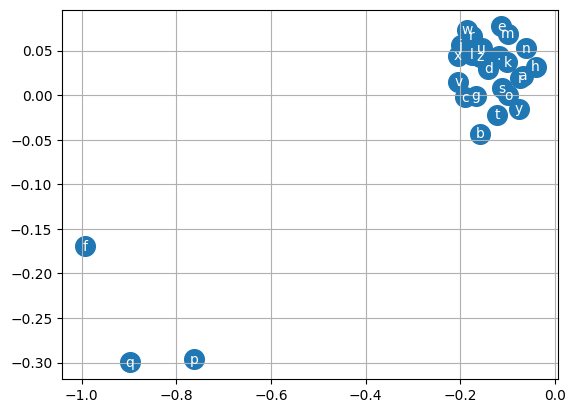

In [ ]:
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)
for i in range(C.shape[0]):
  plt.text(C[i, 0].item(), C[i, 1].item(), itos[i], ha="center", va="center", color="white")
plt.grid("minor")

 ## Wavenet

In [ ]:
block_size = 3
chars = 27
n_emb = 10
hidden = 200
out = 27
# parameters intializations

C = torch.randn(chars, n_emb)
w1 = torch.randn(block_size*n_emb, hidden)
b1 = torch.randn(hidden)
w2 = torch.randn(hidden, hidden)
b2 = torch.randn(hidden)
w3 = torch.randn(hidden, hidden)
b3 = torch.randn(hidden)
w4 = torch.randn(hidden, n_words)
b4 = torch.randn(n_words)
parameters = [C, w1, b1, w2, b2, w3, b3, w4, b4]
for p in parameters:
  p.requires_grad=True

In [ ]:
epochs = 100000
lr = 0.1
lossi = []

In [ ]:
for i in range(epochs):
  # Forward Pass
  ix = torch.randint(0, len(Xtr), (32,))
  emb = C[Xtr[ix]]
  hpreact1 = emb.view(-1, block_size*n_emb) @ w1 + b1
  hact1 = torch.tanh(hpreact1)
  hpreact2 = hact1 @ w2 + b2
  hact2 = torch.tanh(hpreact2)
  hpreact3 = hact2 @ w3 + b3
  hact3 = torch.tanh(hpreact3)
  logits = hact3 @ w4 + b4
  nll = F.cross_entropy(logits, ytr[ix])

  # Backward Pass
  for p in parameters:
    p.grad = None
  nll.backward()

  # update parameters
  with torch.no_grad():
    for p in parameters:
      p += - lr * p.grad
  lossi.append(nll.item())
  if i%(epochs/20) == 0:
    print(f"Chkpt {i}        Loss {nll.item()}")

Chkpt 0        Loss 26.737401962280273
Chkpt 5000        Loss 3.080087423324585
Chkpt 10000        Loss 2.491265058517456
Chkpt 15000        Loss 3.0080649852752686
Chkpt 20000        Loss 2.8513548374176025
Chkpt 25000        Loss 2.44671893119812
Chkpt 30000        Loss 2.8137218952178955
Chkpt 35000        Loss 2.5506415367126465
Chkpt 40000        Loss 2.889261484146118
Chkpt 45000        Loss 3.4211156368255615
Chkpt 50000        Loss 2.8319218158721924
Chkpt 55000        Loss 2.570030927658081
Chkpt 60000        Loss 2.660637378692627
Chkpt 65000        Loss 2.951291799545288
Chkpt 70000        Loss 2.489607810974121
Chkpt 75000        Loss 2.614871025085449
Chkpt 80000        Loss 2.603123426437378
Chkpt 85000        Loss 2.8726766109466553
Chkpt 90000        Loss 3.354188919067383
Chkpt 95000        Loss 4.651370048522949


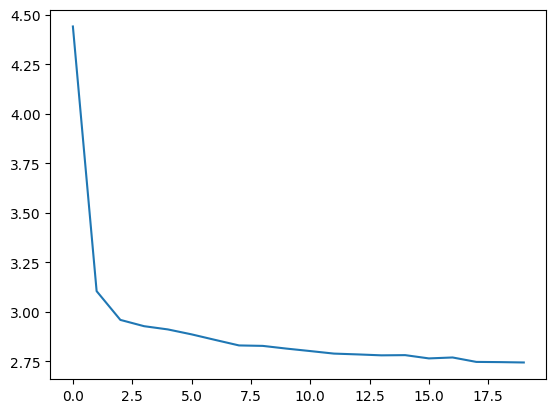

In [ ]:
plt.plot(torch.tensor(lossi).view(-1, epochs//20).mean(dim=1))

In [ ]:
# Train loss
emb = C[Xtr]
hpreact1 = emb.view(-1, block_size*n_emb) @ w1 + b1
hact1 = torch.tanh(hpreact1)
hpreact2 = hact1 @ w2 + b2
hact2 = torch.tanh(hpreact2)
hpreact3 = hact2 @ w3 + b3
hact3 = torch.tanh(hpreact3)
logits = hact3 @ w4 + b4
nll = F.cross_entropy(logits, ytr)
nll

tensor(3.0733, grad_fn=<NllLossBackward0>)

In [ ]:
# Val loss
emb = C[Xdev]
hpreact1 = emb.view(-1, block_size*n_emb) @ w1 + b1
hact1 = torch.tanh(hpreact1)
hpreact2 = hact1 @ w2 + b2
hact2 = torch.tanh(hpreact2)
hpreact3 = hact2 @ w3 + b3
hact3 = torch.tanh(hpreact3)
logits = hact3 @ w4 + b4
nll = F.cross_entropy(logits, ydev)
nll

tensor(3.2086, grad_fn=<NllLossBackward0>)

In [ ]:
# Test loss
emb = C[Xte]
hpreact1 = emb.view(-1, block_size*n_emb) @ w1 + b1
hact1 = torch.tanh(hpreact1)
hpreact2 = hact1 @ w2 + b2
hact2 = torch.tanh(hpreact2)
hpreact3 = hact2 @ w3 + b3
hact3 = torch.tanh(hpreact3)
logits = hact3 @ w4 + b4
nll = F.cross_entropy(logits, yte)
nll

tensor(3.1822, grad_fn=<NllLossBackward0>)

In [ ]:
# predicion
for _ in range(5):
  out = []
  context = [0] * block_size
  while True:
    emb = C[torch.tensor(context)]
    hpreact1 = emb.view(-1, block_size*n_emb) @ w1 + b1
    hact1 = torch.tanh(hpreact1)
    hpreact2 = hact1 @ w2 + b2
    hact2 = torch.tanh(hpreact2)
    hpreact3 = hact2 @ w3 + b3
    hact3 = torch.tanh(hpreact3)
    logits = hact3 @ w4 + b4
    probs = F.softmax(logits, dim=1)
    ix = torch.multinomial(probs, num_samples=1).item()
    if ix == 0:
      break
    context = context[1:] + [ix]
    out.append(ix)
  print("".join([itos[i] for i in out]))

kesmey
sihoem
keton
ihie
ehi


# Genrative Pretrained model (!transformer)

In [ ]:
text = open("/content/ramayan_nano_gpt.txt").read()[298:]
total = len(text)

In [ ]:
words = sorted(list(set(text)))
itos = dict(enumerate(words))
stoi = {v: k for k, v in itos.items()}
n_words = len(words)
encode = lambda x: torch.tensor([stoi[ch] for ch in x])
decode = lambda x: "".join([itos[i.item()] for i in x])
decode(encode("sdf"))

'sdf'

In [ ]:
block_size = 50
chars = n_words
n_emb = 10
hidden = 200
# parameters intializations

C = torch.randn(chars, n_emb)  * 0.1
w1 = torch.randn(block_size*n_emb, hidden) * 0.1
b1 = torch.randn(hidden) * 0.0
w2 = torch.randn(hidden, hidden) * 0.1
b2 = torch.randn(hidden) * 0.0
w3 = torch.randn(hidden, hidden) * 0.1
b3 = torch.randn(hidden) * 0.0
w4 = torch.randn(hidden, n_words) * 0.1
b4 = torch.randn(n_words) * 0.0
parameters = [C, w1, b1, w2, b2, w3, b3, w4, b4]
for p in parameters:
  p.requires_grad=True

In [ ]:
epochs = 100000
lr = 0.01
lossi = []

In [ ]:
for i in range(epochs):
  # Forward Pass
  ix = torch.randint(0, len(text)-block_size-1, (1,)) # Random idx
  y = encode(text[ix+block_size])
  xenc = encode(text[ix:ix+block_size]) # encoded random text
  emb = C[xenc]
  hpreact1 = emb.view(-1, block_size*n_emb) @ w1 + b1
  hact1 = torch.tanh(hpreact1)
  hpreact2 = hact1 @ w2 + b2
  hact2 = torch.tanh(hpreact2)
  hpreact3 = hact2 @ w3 + b3
  hact3 = torch.tanh(hpreact3)
  logits = hact3 @ w4 + b4
  nll = F.cross_entropy(logits, y)

  # Backward Pass
  for p in parameters:
    p.grad = None
  nll.backward()

  # update parameters
  with torch.no_grad():
    for p in parameters:
      p += - lr * p.grad
  lossi.append(nll.item())
  if i%(epochs/20) == 0:
    print(f"Chkpt {i}        Loss {nll.item()}")

Chkpt 0        Loss 0.01957000605762005
Chkpt 5000        Loss 0.0022005646023899317
Chkpt 10000        Loss 1.8113750219345093
Chkpt 15000        Loss 0.09876476228237152
Chkpt 20000        Loss 0.007344271056354046
Chkpt 25000        Loss 0.01312191877514124
Chkpt 30000        Loss 0.0034157049376517534
Chkpt 35000        Loss 0.0004211969207972288
Chkpt 40000        Loss 0.010801891796290874
Chkpt 45000        Loss 0.04760095104575157
Chkpt 50000        Loss 0.002116346498951316
Chkpt 55000        Loss 1.2836716175079346
Chkpt 60000        Loss 0.000459565402707085
Chkpt 65000        Loss 0.015086830593645573
Chkpt 70000        Loss 0.017642119899392128
Chkpt 75000        Loss 0.011093133129179478
Chkpt 80000        Loss 0.007196338847279549
Chkpt 85000        Loss 0.43347635865211487
Chkpt 90000        Loss 0.0021678535267710686
Chkpt 95000        Loss 0.034750670194625854


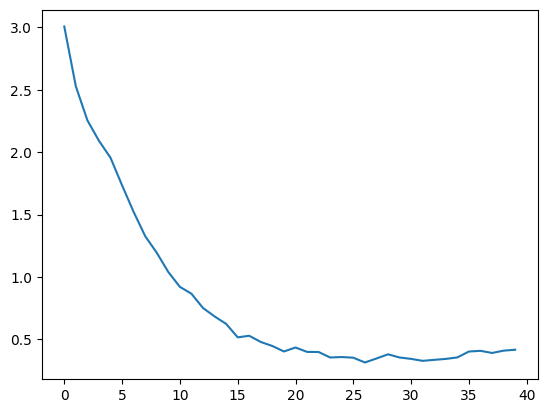

In [ ]:
plt.plot(torch.tensor(lossi).view(-1, epochs//20).mean(dim=1))

In [ ]:
# predicion
out = []
context = [i.item() for i in list(encode(text[500:550]))]
for _ in range(5000):
  emb = C[context]
  hpreact1 = emb.view(-1, block_size*n_emb) @ w1 + b1
  hact1 = torch.tanh(hpreact1)
  hpreact2 = hact1 @ w2 + b2
  hact2 = torch.tanh(hpreact2)
  hpreact3 = hact2 @ w3 + b3
  hact3 = torch.tanh(hpreact3)
  logits = hact3 @ w4 + b4
  probs = F.softmax(logits, dim=1)
  ix = torch.multinomial(probs, num_samples=1).item()
  context = context[1:] + [ix]
  out.append(ix)
print("".join([itos[i] for i in out]))

iplod cregiitr hed bareced thereRa.


Kirr Rara a
was somelf
Affo badata. 
he coma cow sired..
Hhatale wer peapexsed tiringa an icl. Sita ma

sbrnam tr, dem hedlidle cerid.

hathanny ancived
deit and breponsed basem ned cad doregfin tulred.
ya homigcish Iised. Rama d prit .

Ttasm oy Arowara gepakd rns wefn tereron. Hanu aargr tre pond brich. Sitgaward Se ws Rema. Trerung,.
Ha sampttitm Tidngces sbefsibd to ared Rama lgre ced dedet on whed te toli ved ins.

Ttor ad gn aushed Anctamly mand,. Hrala a ptouced the adegh avperin, hud tarngdas brwef gred gice tares aos mores fed owhed int rrey sed. 
ok KaRama.

Rama and Biorise rer thec. Rala ard Lan ma'vh rath.

Vithma rer vaed hike data d to hact jad ced an som. Hen poml somend ta rowam, whoulen fhegtuive phencrell ind tor as ised. He piluth- ond toterd les avd touevheg ta revarbepty griwsta wed himens rost aed trem

Rana. BD The shaousgly dere the ted turey. Haty. -:rrin pom Rama anded bice.
R
Jaovh  Raf
Aind, fna gacacmeffby dhaty d bnav